In [1]:
import warnings
import math
from contextlib import contextmanager

from IPython.display import display, HTML, SVG

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np

import neutcurve
from neutcurve.colorschemes import CBPALETTE
from neutcurve.colorschemes import CBMARKERS

from plotnine import *

import yaml

print(f"Using `neutcurve` version {neutcurve.__version__}")

Using `neutcurve` version 2.1.0


In [2]:
warnings.simplefilter('ignore')
theme_set(theme_seaborn(style='white', context='talk', font_scale=1))

In [3]:
# Publication figure-formatting helpers (from Multi-mut_nirsevimab.ipynb)
@contextmanager
def publication_svg_style():
    original_rcParams = mpl.rcParams.copy()
    mpl.rcParams['svg.fonttype'] = 'none'
    mpl.rcParams['font.family'] = 'sans-serif'
    mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    mpl.rcParams['mathtext.fontset'] = 'custom'
    mpl.rcParams['mathtext.rm'] = 'Arial'
    mpl.rcParams['mathtext.it'] = 'Arial:italic'
    mpl.rcParams['mathtext.bf'] = 'Arial:bold'
    mpl.rcParams['axes.linewidth'] = 0.5
    mpl.rcParams['xtick.major.width'] = 0.5
    mpl.rcParams['ytick.major.width'] = 0.5
    mpl.rcParams['xtick.minor.width'] = 0.5
    mpl.rcParams['ytick.minor.width'] = 0.5
    mpl.rcParams['lines.linewidth'] = 0.5
    mpl.rcParams['lines.markersize'] = 4
    mpl.rcParams['lines.markeredgecolor'] = 'auto'
    mpl.rcParams['lines.markeredgewidth'] = 0.25
    mpl.rcParams['legend.edgecolor'] = 'none'
    try:
        yield
    finally:
        mpl.rcParams.update(original_rcParams)

def format_neutcurve_axes(axes, stroke=0.5):
    # `stroke` sets the linewidth of the curve lines, error bars and their caps.
    if isinstance(axes, np.ndarray):
        axes_list = list(axes.flat)
    elif isinstance(axes, (list, tuple)):
        axes_list = axes
    else:
        axes_list = [axes]

    for ax in axes_list:
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

        ax.tick_params(width=0.5)

        for line in ax.lines:
            line.set_linewidth(stroke)
            line.set_markeredgewidth(0.25)
            if line.get_marker() in ['_', '|']:  # error-bar caps
                line.set_markeredgewidth(stroke)

        for collection in ax.collections:  # error-bar lines
            collection.set_linewidth(stroke)

        legend = ax.get_legend()
        if legend:
            legend.get_frame().set_linewidth(0.5)

In [4]:
df = pd.read_csv('Fab_IgG_RSM01_1B6_1A2_Nirsev_Cles_FractInfect_Final.csv', encoding='utf-8-sig')

# Data cleanup for the "Final" file:
# - Strip stray whitespace from `serum` and `virus`. Some rows carry trailing
#   spaces ('RSM01 IgG ', 'RSV A Long ', 'RSV A B1 '); without stripping these
#   form separate, single-point groups that make the HillCurve fit raise
#   IndexError, and the curve/IC50 code (which looks up the clean names
#   'RSV A Long'/'RSV B B1') silently drops the affected antibodies.
# - The RSV-B virus is mislabeled 'RSV A B1'; the B1 strain is RSV subtype B
#   everywhere else, so relabel it 'RSV B B1'.
df['serum'] = df['serum'].str.strip()
df['virus'] = df['virus'].str.strip().replace({'RSV A B1': 'RSV B B1'})

# After cleanup every antibody has RSV A Long and RSV B B1 with replicates 1 & 2.


In [5]:
# RSM01's IgG/RSV-A and Fab/RSV-B curves otherwise fit to near-vertical "step
# function" slopes (~19 and ~13). Constrain RSM01's Hill slope to (0.5, 2);
# fit every other antibody unconstrained as before. Kept as two CurveFits
# objects (rather than combineCurveFits) so each retains its own fixslope and
# its 'average' curves fit correctly.
is_rsm01 = df['serum'].str.startswith('RSM01')

fits = neutcurve.curvefits.CurveFits(
            data=df[~is_rsm01],
            conc_col='concentration (nM)',
            fixbottom=0,
            )

fits_rsm01 = neutcurve.curvefits.CurveFits(
            data=df[is_rsm01],
            conc_col='concentration (nM)',
            fixbottom=0,
            fixslope=(0.5, 2),
            )

fitParams = pd.concat(
    [fits.fitParams(ics=[10, 50, 90, 95, 97, 98, 99]),
     fits_rsm01.fitParams(ics=[10, 50, 90, 95, 97, 98, 99])],
    ignore_index=True,
)

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


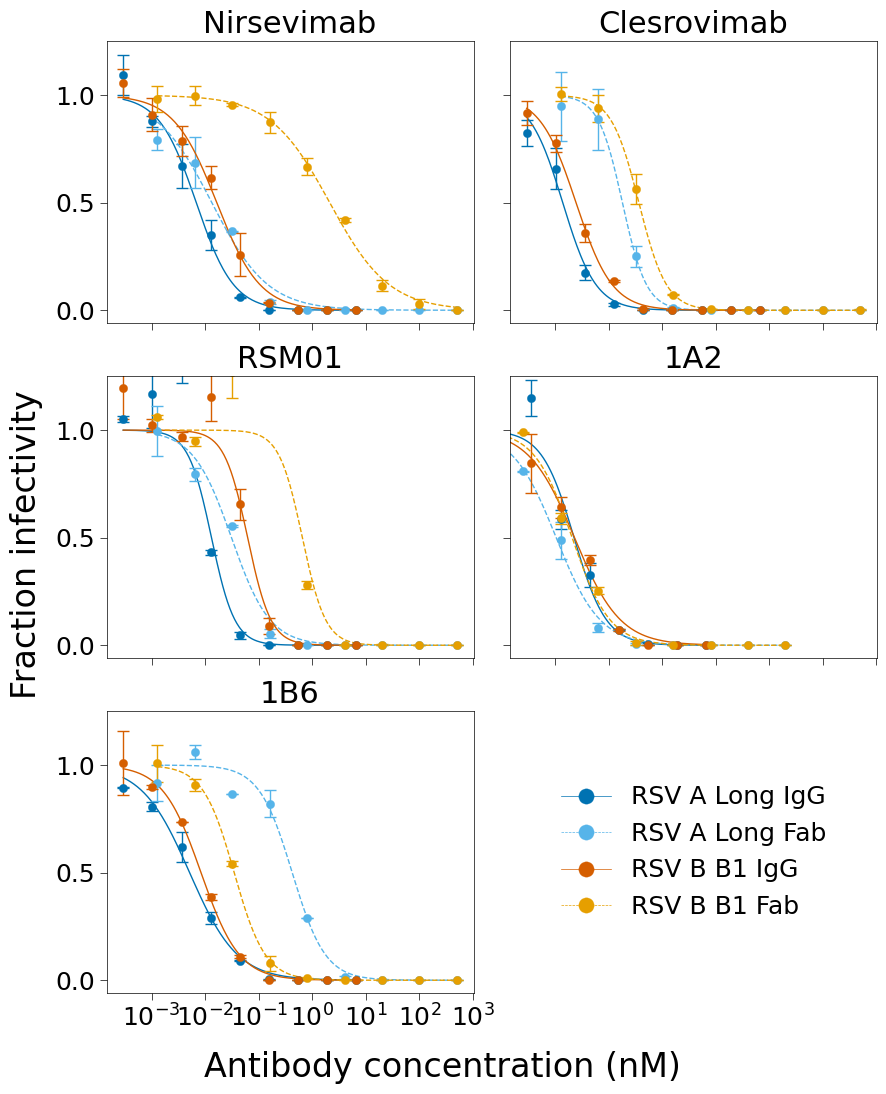

(<Figure size 900x1100 with 6 Axes>,
 array([[<Axes: title={'center': 'Nirsevimab'}>,
         <Axes: title={'center': 'Clesrovimab'}>],
        [<Axes: title={'center': 'RSM01'}>,
         <Axes: title={'center': '1A2'}>],
        [<Axes: title={'center': '1B6'}>, <Axes: >]], dtype=object))

In [6]:
# Per-antibody IgG vs Fab neutralization curves for RSV A Long and RSV B B1.
# Blue = RSV A (Fab lighter + dashed), orange = RSV B (Fab lighter + dashed).
NEUT_STYLE = {
    ('RSV A Long', 'IgG'): dict(color='#0072B2', linestyle='-',  label='RSV A Long IgG'),
    ('RSV A Long', 'Fab'): dict(color='#56B4E9', linestyle='--', label='RSV A Long Fab'),
    ('RSV B B1',   'IgG'): dict(color='#D55E00', linestyle='-',  label='RSV B B1 IgG'),
    ('RSV B B1',   'Fab'): dict(color='#E69F00', linestyle='--', label='RSV B B1 Fab'),
}

# Larger fonts for the neut-curve figures.
TITLE_FS, LABEL_FS, TICK_FS, LEGEND_FS = 22, 22, 18, 18


def plot_neut_panels(panel_layout, figsize, outfile, legend_loc=None, label_fs=LABEL_FS,
                     stroke=1, markersize=4, legend_markersize=None):
    """One panel per antibody: IgG/Fab curves vs RSV A Long & RSV B B1.

    panel_layout: dict mapping (row, col) -> antibody name.
    legend_loc: (row, col) of a blank cell to host the shared legend, or None
                to place a figure-level legend to the right of the panels.
    label_fs: font size for the shared x/y axis labels.
    stroke: linewidth for the curve lines, error bars and their caps.
    markersize: size of the data-point markers.
    legend_markersize: size of the legend markers (defaults to `markersize`).
    """
    if legend_markersize is None:
        legend_markersize = markersize
    nrows = max(r for r, _ in panel_layout) + 1
    ncols = max(c for _, c in panel_layout) + 1
    with publication_svg_style():
        mpl.rcParams['lines.markersize'] = markersize
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
        for (r, c), ab in panel_layout.items():
            ax = axes[r, c]
            for virus in ['RSV A Long', 'RSV B B1']:
                for form in ['IgG', 'Fab']:
                    st = NEUT_STYLE[(virus, form)]
                    # RSM01 is fit with a constrained slope (see fits_rsm01).
                    ab_fits = fits_rsm01 if ab == 'RSM01' else fits
                    curve = ab_fits.getCurve(serum=f'{ab} {form}', virus=virus,
                                             replicate='average')
                    curve.plot(ax=ax, color=st['color'], linestyle=st['linestyle'],
                               marker='o', draw_in_bounds=True,
                               yticklocs=[0, 0.5, 1.0], xlabel='', ylabel='')
            ax.set_title(ab, fontsize=TITLE_FS)
            ax.tick_params(labelsize=TICK_FS)
            # Cap the y-axis at 1.25 (ticks stay at 0/0.5/1.0, so 1.25 is unlabeled).
            ax.set_ylim(top=1.25)

        # blank any unused grid cells
        used = set(panel_layout)
        for r in range(nrows):
            for c in range(ncols):
                if (r, c) not in used:
                    axes[r, c].axis('off')

        handles = [Line2D([], [], color=s['color'], linestyle=s['linestyle'],
                          marker='o', markersize=legend_markersize, label=s['label'])
                   for s in NEUT_STYLE.values()]
        if legend_loc is not None:
            axes[legend_loc].legend(handles=handles, loc='center',
                                    frameon=False, fontsize=LEGEND_FS)
        else:
            fig.legend(handles=handles, loc='center left',
                       bbox_to_anchor=(0.98, 0.5), frameon=False, fontsize=LEGEND_FS)

        fig.supxlabel('Antibody concentration (nM)', fontsize=label_fs)
        fig.supylabel('Fraction infectivity', fontsize=label_fs)

        format_neutcurve_axes(axes, stroke=stroke)
        fig.tight_layout()
        fig.savefig(f'{outfile}.pdf', dpi=300, bbox_inches='tight')
        fig.savefig(f'{outfile}.svg', format='svg', bbox_inches='tight')
        plt.show()
    return fig, axes


# Combined 3x2 grid (col 1: Nirsevimab/RSM01/1B6, col 2: Clesrovimab/1A2);
# the shared legend lives in the blank bottom-right slot. Formatting matches the
# 2x3 figure below (larger axis labels, larger points and legend markers).
plot_neut_panels(
    {(0, 0): 'Nirsevimab', (1, 0): 'RSM01', (2, 0): '1B6',
     (0, 1): 'Clesrovimab', (1, 1): '1A2'},
    figsize=(9, 11),
    outfile='Neut_IgG_vs_Fab_by_antibody',
    legend_loc=(2, 1),
    label_fs=24,
    markersize=8,
    legend_markersize=11,
)

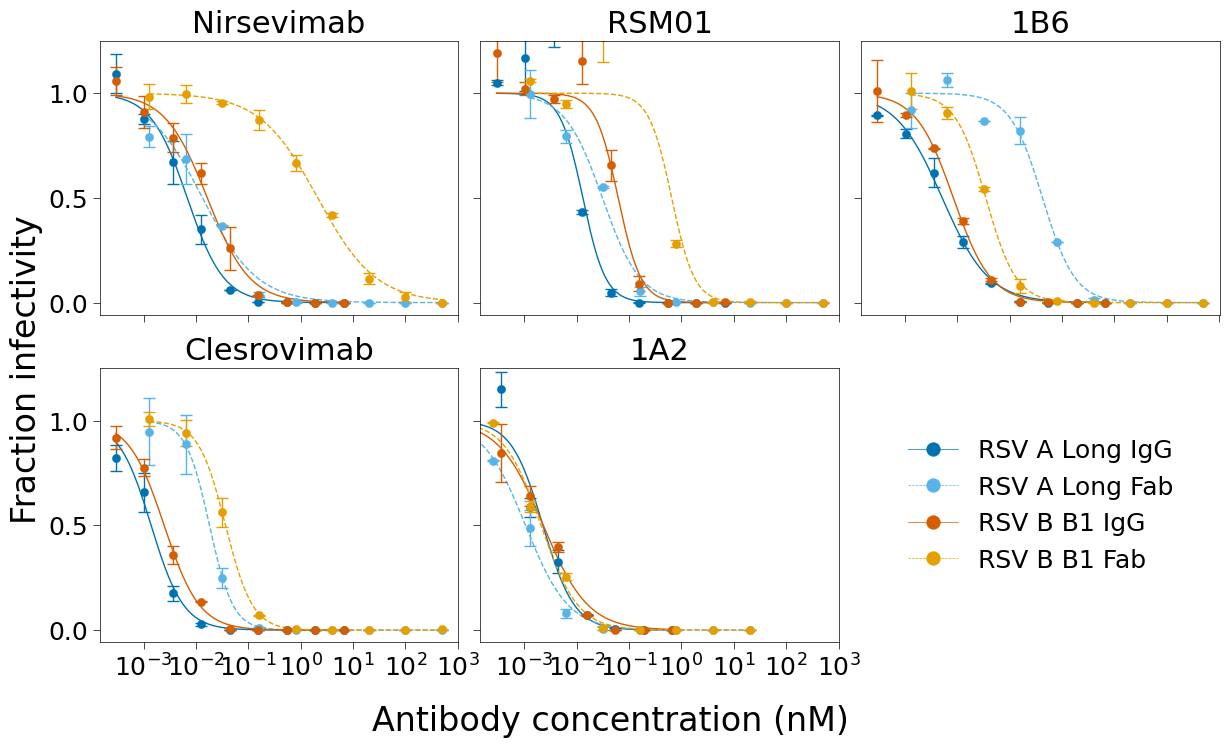

(<Figure size 1250x750 with 6 Axes>,
 array([[<Axes: title={'center': 'Nirsevimab'}>,
         <Axes: title={'center': 'RSM01'}>,
         <Axes: title={'center': '1B6'}>],
        [<Axes: title={'center': 'Clesrovimab'}>,
         <Axes: title={'center': '1A2'}>, <Axes: >]], dtype=object))

In [7]:
# Two-row figure: top row Nirsevimab / RSM01 / 1B6, bottom row Clesrovimab / 1A2.
# Slightly wider panels, larger axis-label text and larger data points.
plot_neut_panels(
    {(0, 0): 'Nirsevimab',  (0, 1): 'RSM01', (0, 2): '1B6',
     (1, 0): 'Clesrovimab', (1, 1): '1A2'},
    figsize=(12.5, 7.5),               # a touch wider than before
    outfile='Neut_IgG_vs_Fab_3x2_topNirsevimabRSM011B6',
    legend_loc=(1, 2),                 # shared legend in the empty bottom-right cell
    label_fs=24,                       # larger than default (22) but smaller than before (28)
    markersize=18,                      # larger data points
    legend_markersize=10,              # slightly larger markers in the legend
)

In [8]:
fitParams = pd.concat(
    [fits.fitParams(ics=[10, 50, 90, 95, 97, 98, 99]),
     fits_rsm01.fitParams(ics=[10, 50, 90, 95, 97, 98, 99])],
    ignore_index=True,
)
fitParams

,serum,virus,replicate,nreplicates,ic10,ic10_bound,ic10_str,ic50,ic50_bound,ic50_str,...,ic99_bound,ic99_str,midpoint,midpoint_bound,midpoint_bound_type,slope,top,bottom,r2,rmsd
0,Clesrovimab IgG,RSV A Long,average,2,0.000296,upper,<0.000296,0.001396,interpolated,0.0014,...,interpolated,0.0372,0.001396,0.001396,interpolated,1.399518,1.0,0.0,0.987948,0.033231
1,Clesrovimab IgG,RSV B B1,average,2,0.000447,interpolated,0.000447,0.002473,interpolated,0.00247,...,interpolated,0.0885,0.002473,0.002473,interpolated,1.284573,1.0,0.0,0.997740,0.016282
2,Clesrovimab Fab,RSV A Long,average,2,0.005821,interpolated,0.00582,0.018153,interpolated,0.0182,...,interpolated,0.196,0.018153,0.018153,interpolated,1.931687,1.0,0.0,0.998260,0.015601
3,Clesrovimab Fab,RSV B B1,average,2,0.009991,interpolated,0.00999,0.036791,interpolated,0.0368,...,interpolated,0.562,0.036791,0.036791,interpolated,1.685616,1.0,0.0,0.999824,0.005364
4,1B6 IgG,RSV A Long,average,2,0.000538,interpolated,0.000538,0.005137,interpolated,0.00514,...,interpolated,0.576,0.005137,0.005137,interpolated,0.973719,1.0,0.0,0.995314,0.024100
5,1B6 IgG,RSV B B1,average,2,0.001371,interpolated,0.00137,0.008384,interpolated,0.00838,...,interpolated,0.37,0.008384,0.008384,interpolated,1.213354,1.0,0.0,0.998229,0.016777
6,1B6 Fab,RSV A Long,average,2,0.088311,interpolated,0.0883,0.422656,interpolated,0.423,...,interpolated,11.2,0.422656,0.422656,interpolated,1.403354,1.0,0.0,0.986255,0.051347
7,1B6 Fab,RSV B B1,average,2,0.008045,interpolated,0.00804,0.034877,interpolated,0.0349,...,interpolated,0.749,0.034877,0.034877,interpolated,1.497980,1.0,0.0,0.999295,0.010545
8,Nirsevimab IgG,RSV A Long,average,2,0.001173,interpolated,0.00117,0.006835,interpolated,0.00684,...,interpolated,0.272,0.006835,0.006835,interpolated,1.246912,1.0,0.0,0.988949,0.042991
9,Nirsevimab IgG,RSV B B1,average,2,0.002151,interpolated,0.00215,0.016505,interpolated,0.0165,...,interpolated,1.17,0.016505,0.016505,interpolated,1.078323,1.0,0.0,0.990730,0.039557


In [9]:
fitParams.to_csv("IC_values_IgG_Fab.csv")

## IC50 values (IgG vs Fab)

In [10]:
import altair as alt

# Tidy IC50 table (nM, average replicate). The serum column encodes both the
# antibody and the format (IgG/Fab), so split it into separate fields and build
# a virus+format category that matches the curve-plot color scheme.
ic50_df = (
    fitParams.query("replicate == 'average'")[["serum", "virus", "ic50"]]
    .rename(columns={"ic50": "ic50_nM"})
    .reset_index(drop=True)
)
ic50_df["antibody"] = ic50_df["serum"].str.replace(r"\s+(IgG|Fab)$", "", regex=True)
ic50_df["format"] = ic50_df["serum"].str.extract(r"(IgG|Fab)$")
ic50_df["virus_format"] = ic50_df["virus"] + " " + ic50_df["format"]

ic50_df

,serum,virus,ic50_nM,antibody,format,virus_format
0,Clesrovimab IgG,RSV A Long,0.001396,Clesrovimab,IgG,RSV A Long IgG
1,Clesrovimab IgG,RSV B B1,0.002473,Clesrovimab,IgG,RSV B B1 IgG
2,Clesrovimab Fab,RSV A Long,0.018153,Clesrovimab,Fab,RSV A Long Fab
3,Clesrovimab Fab,RSV B B1,0.036791,Clesrovimab,Fab,RSV B B1 Fab
4,1B6 IgG,RSV A Long,0.005137,1B6,IgG,RSV A Long IgG
5,1B6 IgG,RSV B B1,0.008384,1B6,IgG,RSV B B1 IgG
6,1B6 Fab,RSV A Long,0.422656,1B6,Fab,RSV A Long Fab
7,1B6 Fab,RSV B B1,0.034877,1B6,Fab,RSV B B1 Fab
8,Nirsevimab IgG,RSV A Long,0.006835,Nirsevimab,IgG,RSV A Long IgG
9,Nirsevimab IgG,RSV B B1,0.016505,Nirsevimab,IgG,RSV B B1 IgG


In [11]:
# IC50 (nM, log scale) per antibody, colored by virus + format using the same
# scheme as the neutralization-curve figure (blue = RSV A, orange = RSV B;
# lighter shade = Fab). Mirrors make_ic50_chart in RSM01_Neutralization_final.ipynb.
# Both color and shape encode `virus_format` so they merge into a single legend
# showing the four color+shape combinations (circle = IgG, triangle = Fab).
antibody_order = ["Nirsevimab", "RSM01", "1B6", "Clesrovimab", "1A2"]
cat_domain = ["RSV A Long IgG", "RSV A Long Fab", "RSV B B1 IgG", "RSV B B1 Fab"]
cat_range = ["#0072B2", "#56B4E9", "#D55E00", "#E69F00"]

ic50_chart = (
    alt.Chart(ic50_df)
    .mark_point(size=200, filled=True, opacity=1)
    .encode(
        x=alt.X(
            "antibody:N",
            sort=antibody_order,
            title=None,
            axis=alt.Axis(labelAngle=-45),
        ),
        y=alt.Y(
            "ic50_nM:Q",
            title="IC50 (nM)",
            scale=alt.Scale(type="log"),
        ),
        color=alt.Color(
            "virus_format:N",
            scale=alt.Scale(domain=cat_domain, range=cat_range),
            legend=alt.Legend(title=None),
        ),
        shape=alt.Shape(
            "virus_format:N",
            scale=alt.Scale(
                domain=cat_domain,
                range=["circle", "triangle-up", "circle", "triangle-up"],
            ),
            legend=alt.Legend(title=None),
        ),
        tooltip=[
            alt.Tooltip("antibody:N", title="Antibody"),
            alt.Tooltip("virus:N", title="Virus"),
            alt.Tooltip("format:N", title="Format"),
            alt.Tooltip("ic50_nM:Q", title="IC50 (nM)", format=".4f"),
        ],
    )
    .properties(width=max(220, 60 * len(antibody_order)), height=320,
                title="IC50 (nM): IgG vs Fab")
    # Black axis lines/ticks/labels; gray 0.35pt horizontal gridlines.
    .configure_axis(
        labelFontSize=16,
        titleFontSize=18,
        labelColor="black",
        titleColor="black",
        domainColor="black",
        tickColor="black",
    )
    .configure_axisY(gridColor="lightgray", gridWidth=0.35)
    .configure_axisX(grid=False)
    .configure_legend(labelFontSize=15, titleFontSize=15, symbolSize=220)
    .configure_title(fontSize=22)
)

ic50_chart.save("IC50_IgG_vs_Fab.html")
ic50_chart

alt.Chart(...)